In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


In [4]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [5]:
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.13.0+cpu
Torchvision Version: 0.28.0+cpu


##  Load and Preprocess the CIFAR-10 Dataset

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [7]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100.0%


In [8]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [9]:
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

In [10]:
print(f"Training Images : {len(train_dataset)}")
print(f"Testing Images  : {len(test_dataset)}")

print(f"Classes : {classes}")

Training Images : 50000
Testing Images  : 10000
Classes : ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


##  Explore the CIFAR-10 Dataset

In [11]:
images, labels = next(iter(train_loader))

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)


Image Batch Shape: torch.Size([64, 3, 32, 32])
Label Batch Shape: torch.Size([64])


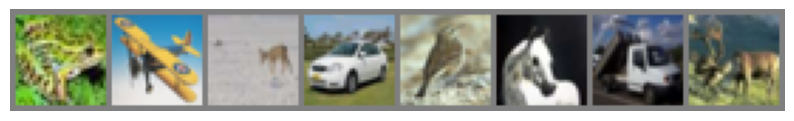

In [12]:
def imshow(img):
    img = img / 2 + 0.5      # Unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

imshow(torchvision.utils.make_grid(images[:8]))

In [13]:
print("Labels:")

for i in range(8):
    print(f"Image {i+1}: {classes[labels[i]]}")

Labels:
Image 1: frog
Image 2: airplane
Image 3: deer
Image 4: automobile
Image 5: bird
Image 6: horse
Image 7: truck
Image 8: deer


In [14]:
print("Minimum Pixel Value:", images.min().item())
print("Maximum Pixel Value:", images.max().item())

Minimum Pixel Value: -1.0
Maximum Pixel Value: 1.0


In [15]:
print(f"Training Samples : {len(train_dataset)}")
print(f"Testing Samples  : {len(test_dataset)}")
print(f"Number of Classes: {len(classes)}")

Training Samples : 50000
Testing Samples  : 10000
Number of Classes: 10


In [16]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # First Convolutional Block
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Max Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        # Convolution -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv1(x)))

        # Convolution -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv2(x)))

        # Flatten
        x = torch.flatten(x, 1)

        # Fully Connected Layer
        x = torch.relu(self.fc1(x))

        # Output Layer
        x = self.fc2(x)

        return x

In [17]:
model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [18]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 545,098


In [19]:
sample_images = torch.randn(4, 3, 32, 32).to(device)

outputs = model(sample_images)

print("Output Shape:", outputs.shape)

Output Shape: torch.Size([4, 10])


In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [21]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    running_loss = 0.0

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

print("Training Complete!")

Epoch [1/10] - Loss: 1.3569
Epoch [2/10] - Loss: 0.9573
Epoch [3/10] - Loss: 0.8049
Epoch [4/10] - Loss: 0.6881
Epoch [5/10] - Loss: 0.5878
Epoch [6/10] - Loss: 0.5006
Epoch [7/10] - Loss: 0.4137
Epoch [8/10] - Loss: 0.3357
Epoch [9/10] - Loss: 0.2738
Epoch [10/10] - Loss: 0.2130
Training Complete!


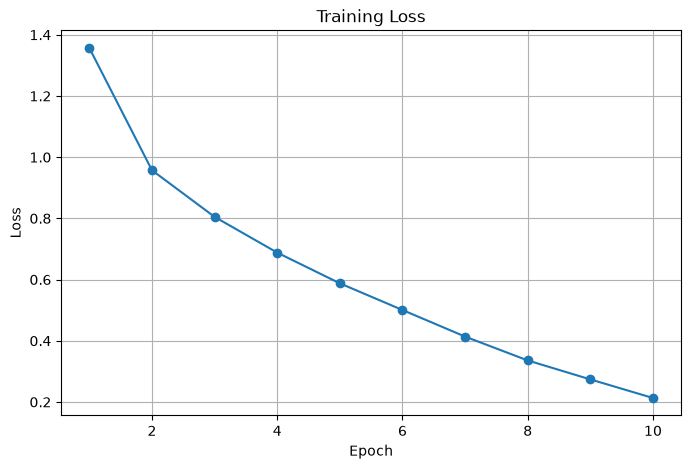

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_epochs + 1), train_losses, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [23]:
torch.save(model.state_dict(), "cnn_cifar10.pth")

print("Model saved successfully!")

Model saved successfully!


##  Evaluate the CNN Model

In [24]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.92%


In [25]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

In [26]:
def imshow(img):
    img = img.cpu() / 2 + 0.5
    npimg = img.numpy()

    plt.figure(figsize=(12,4))
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis("off")
    plt.show()

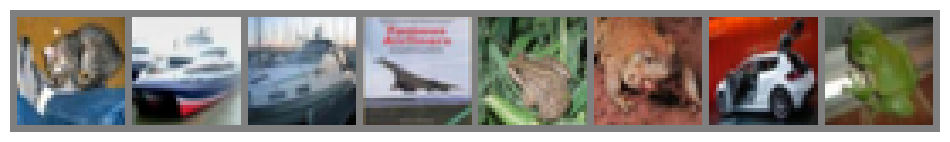

Predicted Labels:
['cat', 'automobile', 'automobile', 'ship', 'frog', 'frog', 'automobile', 'frog']

Actual Labels:
['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']


In [27]:
imshow(torchvision.utils.make_grid(images[:8]))

print("Predicted Labels:")
print([classes[p] for p in predicted[:8].cpu().numpy()])

print("\nActual Labels:")
print([classes[l] for l in labels[:8].cpu().numpy()])